# Геометрические приближения сердца и проверка временных зависимостей

**Вычислительное продолжение методологического обзора 40.15.**

## Аннотация

Исследована потеря геометрической информации при замещении автоматических масок сердца сферой, эллипсоидом и индивидуальной опорной формой с изменением масштаба и положения. Использованы 39 фаз трёх участников и шесть областей в каждой фазе. Основное сравнение включает 198 сочетаний «фаза × область» после исключения 36 опорных сочетаний. Дополнительно проверено восстановление объёма и центра области по остальным фазам того же исходного сердечного цикла.

Эллипсоид превосходит сферу по пространственному перекрытию во всех 198 сравнениях. Индивидуальная форма имеет более высокие медианные показатели перекрытия, однако использует существенно больше исходной информации: полную опорную маску. Эти результаты характеризуют геометрическое приближение автоматической сегментации. Независимая анатомическая точность, сохранение электрического отклика и применимость к новым людям пока не установлены.

## 1. Постановка и происхождение данных

На этапе разработки необходимо установить, какая информация о форме сердца нужна для воспроизведения его электрического влияния. Геометрическое сравнение является первым этапом этой проверки. Оно показывает, какие особенности формы теряются, но не определяет, насколько эти потери существенны для конкретной электродной сборки.

Использованы 12 фаз Adam, 12 фаз Nix и 15 фаз Georg. Маски целого сердца и объединённой области крови приняты из существующих результатов 21.03; маски четырёх камер получены при исходной автоматической сегментации TotalSegmentator. Объединённая область крови и целое сердце имеют разные определения. Их объёмы и свойства не взаимозаменяемы. В настоящем опыте маски не исправлялись.

**Статус входов.** КТ служит источником пространственной системы координат. Маски, объёмы и центры являются результатами автоматической обработки. Принятие этих масок в качестве целевой геометрии — допущение вычислительного опыта. Экспертного анатомического референса в расчёте нет. Проверка сегментации на исторических контрастных КТ выполняется отдельно.

Исходные сердечные циклы сохранены раздельно. Это особенно существенно для двух неодинаковых R–R-интервалов Georg. Первая доступная фаза каждого цикла используется как опорная форма; она не объявляется конечной диастолой. Показанные фазы одного человека зависимы, поэтому число фаз не является числом независимых участников.

In [1]:
from pathlib import Path
import sys, json
from IPython.display import display, Markdown, Image
root = Path.cwd()
if root.name != 'Colab Notebooks':
    root = root / 'Colab Notebooks'
sys.path.insert(0, str(root / 'cardiac_4d_segmentation'))
import heart_geometry_report as report
import matplotlib.pyplot as plt
work = root / 'cardiac_4d_segmentation/results/reduced_heart_geometry_20260914/exploratory'
records = report.load_results(work / 'comparison_02')
temporal = json.loads((work / 'temporal_01/results.json').read_text(encoding='utf-8'))
affine = [json.loads(line) for line in (work / 'affine_01/affine_comparison.jsonl').read_text(encoding='utf-8').splitlines()]
assert len(affine) == 234
assert len(records) == 234
assert len(temporal['predictions']) == 480
figures = work / 'reader_figures'
figures.mkdir(exist_ok=True)
def show_figure(figure, name):
    figure.savefig(figures / name, dpi=170, bbox_inches='tight', facecolor='white')
    display(Image(filename=str(figures / name)))
    plt.close(figure)


## 2. Геометрические модели

Объём области определяется суммой объёмов её вокселей. Центр объёма и нормированная матрица вторых центральных моментов вычисляются в физических координатах NIfTI RAS+, в миллиметрах:

$$V=N|\det A|,\qquad \mathbf c=A\bar{\mathbf i}+\mathbf b,$$

$$C=A\left[\frac{1}{N}\sum_{n=1}^{N}(\mathbf i_n-\bar{\mathbf i})(\mathbf i_n-\bar{\mathbf i})^T+\frac{I}{12}\right]A^T,$$

где $V$ — объём области; $\mathbf c$ — её центр объёма; $C$ — нормированная матрица вторых центральных моментов; $N$ — число вокселей области; $A$ и $\mathbf b$ — линейная часть и вектор переноса при переходе от индексов к физическим координатам; $\mathbf i_n$ — индекс центра $n$-го вокселя; $\bar{\mathbf i}$ — среднее индексов центров всех вокселей области; $I$ — единичная матрица; верхний индекс $T$ обозначает транспонирование. Координаты $\mathbf c$ выражены в миллиметрах, элементы $C$ — в мм². Слагаемое $I/12$ учитывает собственный размер вокселя. При использовании миллиметров объём $V$ выражен в мм³; для перевода в миллилитры он делится на 1000.

Сфера имеет центр $\mathbf c$ и радиус $r=\left(\frac{3V}{4\pi}\right)^{1/3}$. Для эллипсоида сначала принимаются полуоси $a_i=\sqrt{5\lambda_i}$ по собственным значениям $\lambda_i$ матрицы $C$, затем все полуоси умножаются на общий коэффициент, обеспечивающий объём $V$. После этого сохраняются направления и отношения полуосей, но исходная матрица вторых моментов в общем случае уже не сохраняется точно. Собственные направления не отождествляются с анатомическими осями сердца.

Индивидуальная форма получается преобразованием опорной маски:

$$\mathbf x_t=\mathbf c_t+s_t(\mathbf x_0-\mathbf c_0),\qquad s_t=(V_t/V_0)^{1/3},$$

где $\mathbf x_0$ и $\mathbf x_t$ — физические координаты соответствующих точек опорной и преобразованной областей; $\mathbf c_0$ и $\mathbf c_t$ — центры объёма опорной и целевой масок; $V_0$ и $V_t$ — их объёмы; $s_t$ — безразмерный коэффициент равномерного масштабирования. Индекс 0 относится к опорной фазе, а $t$ — к рассматриваемой фазе. В начальном варианте поворот и неравномерная деформация отсутствуют. Все три кандидата используют объём и центр самой целевой фазы. Следовательно, этот опыт проверяет представление формы при известных параметрах, а не способность предсказать движение.

## 3. Критерий геометрического сравнения

Для исходной маски $M$ и кандидата $G$ вычисляется коэффициент пространственного перекрытия Dice:

$$D=\frac{2|M\cap G|}{|M|+|G|},$$

где $D$ — коэффициент Dice; $|M|$ и $|G|$ — числа узлов сетки центров исходных вокселей, принадлежащих соответственно маске и кандидату; $|M\cap G|$ — число узлов, общих для обеих областей. Значение 1 означает полное совпадение дискретных областей, значение 0 — отсутствие перекрытия. Сетка расширяется так, чтобы целиком включать и маску, и кандидата. Области кандидата за границами исходного массива учитываются в знаменателе. Нулевое продолжение маски за пределами КТ является вычислительным соглашением и не устанавливает реальную анатомию вне поля изображения.

Опорные фазы исключаются из сравнительных сводок всех моделей: индивидуальная форма совпадает с ними по построению. Увеличение Dice означает улучшение геометрического перекрытия. Оно само по себе не является ни оценкой ошибки объёма, ни доказательством улучшения электрического приближения.

## 4. Результаты сравнения формы

В таблице приведены медианы Dice по 33 неопорным фазам для каждой области. Медианы характеризуют имеющийся набор фаз; доверительные интервалы для популяции по этим данным не рассчитывались.

In [2]:
display(Markdown(report.geometry_table(records)))

| Область | Число фаз | Сфера | Эллипсоид | Индивидуальная форма |
| --- | --- | --- | --- | --- |
| Целое сердце | 33 | 0,712 | 0,789 | 0,923 |
| Объединённая область крови | 33 | 0,659 | 0,751 | 0,897 |
| Левый желудочек | 33 | 0,709 | 0,870 | 0,947 |
| Правый желудочек | 33 | 0,674 | 0,774 | 0,936 |
| Левое предсердие | 33 | 0,750 | 0,914 | 0,933 |
| Правое предсердие | 33 | 0,759 | 0,856 | 0,912 |

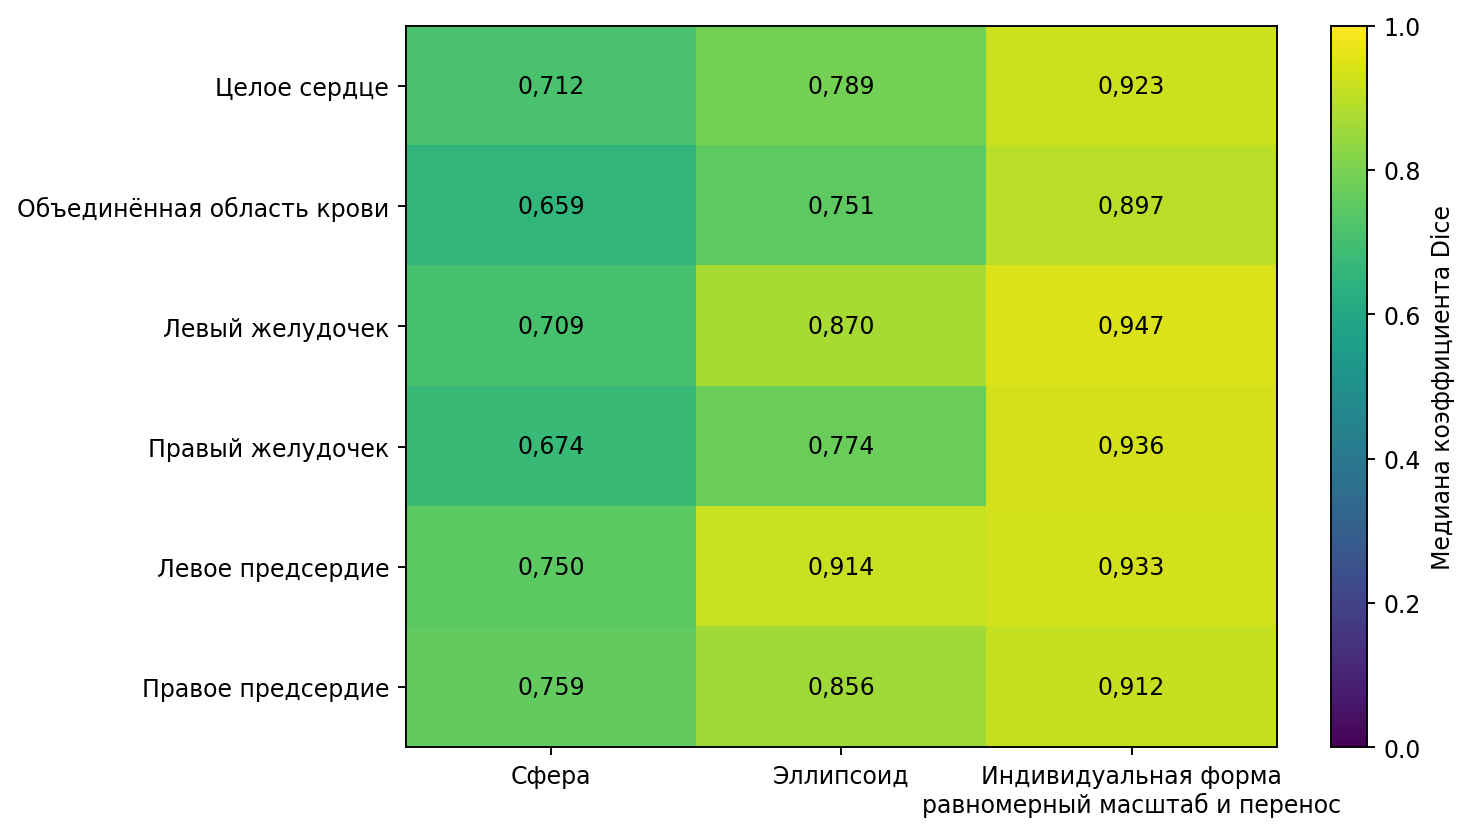

In [3]:
show_figure(report.overlap_figure(records), '01_overlap.png')

**Рисунок 1. Пространственное перекрытие трёх геометрических представлений с автоматическими масками.** Цветовая шкала едина для всех областей и моделей, от 0 до 1. Более светлая ячейка соответствует большему перекрытию. В ячейках приведены медианы Dice.

Для целого сердца медиана Dice составляет приблизительно 0,712 у сферы, 0,789 у эллипсоида и 0,923 у индивидуальной формы. Для объединённой области крови — 0,659, 0,751 и 0,897 соответственно. Эллипсоид уменьшает потерю формы относительно сферы, но сохраняет только грубую пространственную структуру. Индивидуальная форма дополнительно сохраняет особенности исходной поверхности.

Преимущество индивидуальной модели не означает, что она даёт такое же качество при наличии только объёма и трёх координат центра. Помимо текущих объёма и центра ей требуется вся опорная маска. При дальнейшем сокращении входных данных необходимость этой дополнительной геометрической информации должна учитываться отдельно.

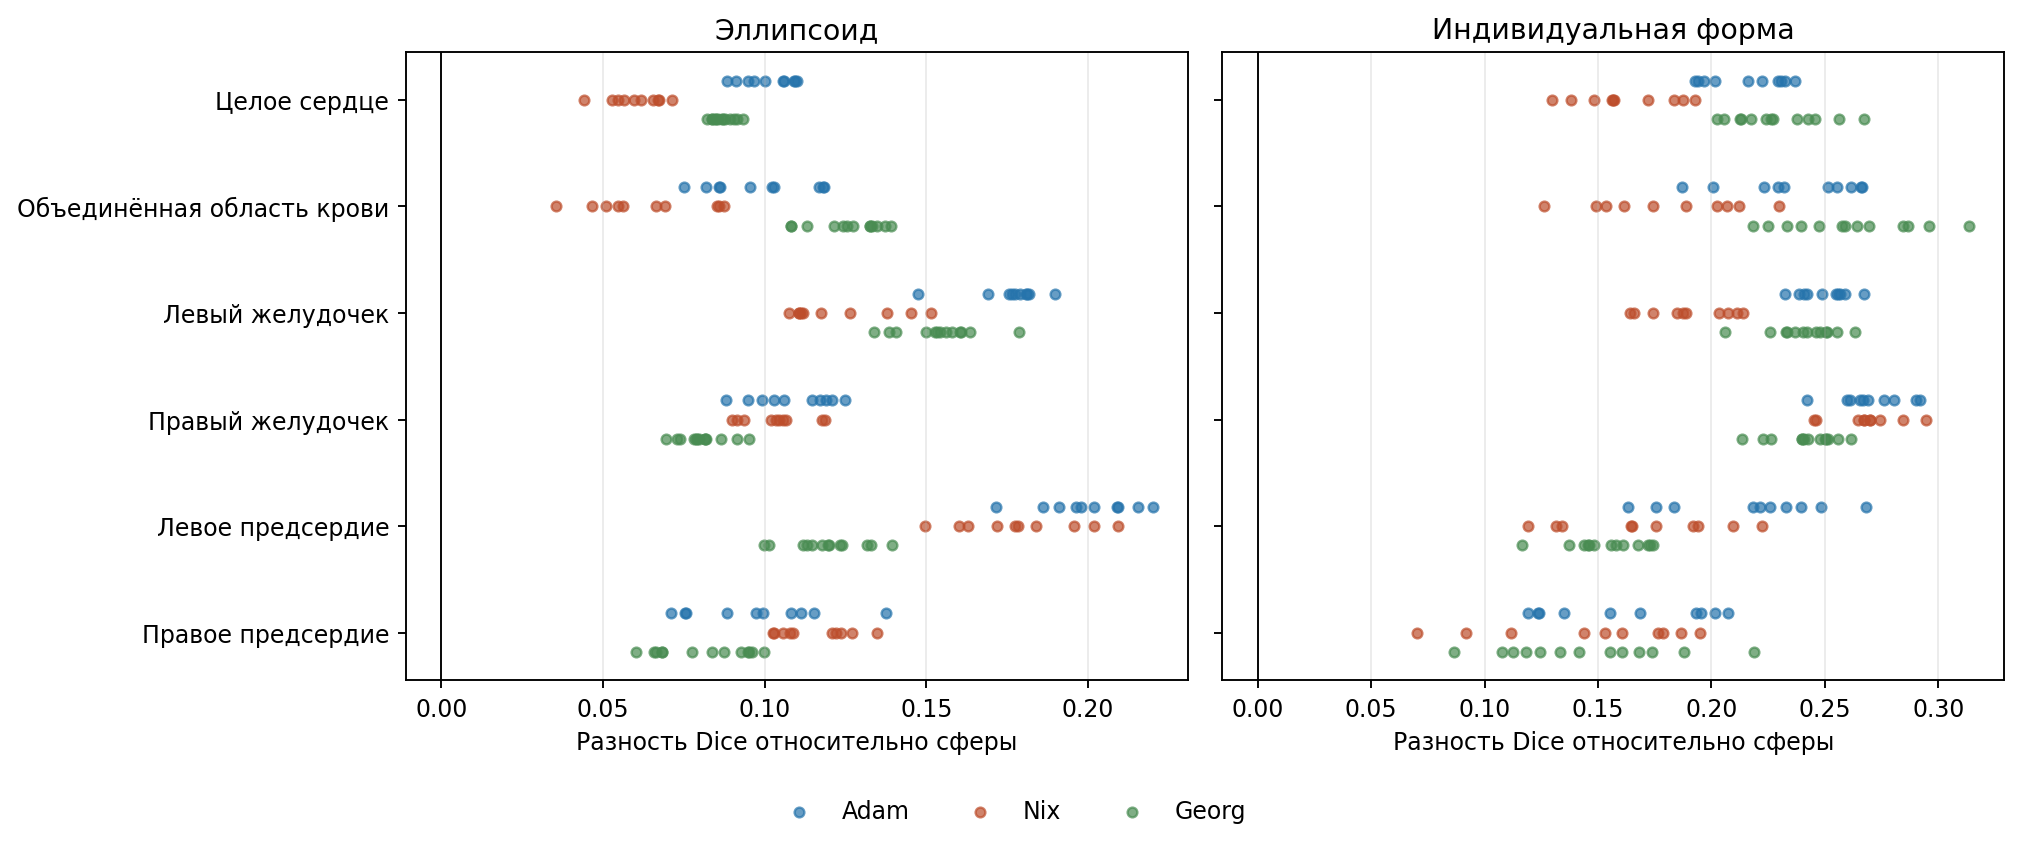

In [4]:
show_figure(report.paired_figure(records), '02_paired.png')

**Рисунок 2. Парное изменение Dice относительно сферы.** Каждая точка относится к одной и той же фазе и области, представленной двумя способами. Положительное значение означает преимущество указанного кандидата. Цвет обозначает участника. Опорные фазы исключены.

Все 198 разностей «эллипсоид минус сфера» положительны. Следовательно, наблюдаемое преимущество эллипсоида не возникает только из-за усреднения разных фаз. Однако улучшение формы ещё не определяет предпочтение в электрической задаче: разные участки поверхности могут иметь разный вклад в измеряемый сигнал.


## 4.1. Добавление поворота и неравномерного масштабирования

На тех же 234 сочетаниях дополнительно рассчитаны два преобразования индивидуальной опорной формы. Первое добавляет поворот к равномерному масштабированию и переносу. Второе использует разные коэффициенты масштабирования по трём главным направлениям, поворот и перенос. Главные направления сопоставляются по убыванию собственных значений матрицы вторых моментов. Из четырёх допустимых сочетаний знаков выбирается поворот с наименьшим углом, сохраняющий ориентацию пространства. Такая процедура определяет вычислительное соответствие осей; она не измеряет анатомическое вращение сердца.

Линейная часть преобразования с неравномерным масштабированием задаётся выражением

$$F=kQ_t\operatorname{diag}\left(\sqrt{\lambda_{t,i}/\lambda_{0,i}}\right)Q_0^T,$$

где $F$ — линейная часть преобразования; столбцы $Q_0$ и $Q_t$ задают согласованные главные направления опорной и целевой масок; $\lambda_{0,i}$ и $\lambda_{t,i}$ — соответствующие собственные значения матриц вторых моментов; $\operatorname{diag}$ обозначает диагональную матрицу; общий коэффициент $k$ выбран так, чтобы $\det F=V_t/V_0$. Итоговое преобразование имеет вид $\mathbf x_t=\mathbf c_t+F(\mathbf x_0-\mathbf c_0)$. Оно сохраняет заданный объём и отношения масштабов. Матрица вторых моментов преобразованной формы равна $k^2C_t$ и в общем случае отличается от $C_t$.

В таблице приведены медианы Dice. Парные изменения и число улучшений рассчитаны для неравномерного масштабирования с поворотом относительно начального варианта с равномерным масштабированием и переносом. Медиана парных разностей вычисляется по отдельным фазам и в общем случае не равна разности медиан.

In [5]:
display(Markdown(report.affine_table(records, affine)))

| Область | Равномерный масштаб и перенос | Равномерный масштаб, поворот и перенос | Неравномерный масштаб, поворот и перенос | Медиана парного изменения Dice | Число фаз с улучшением при неравномерном масштабе |
| --- | --- | --- | --- | --- | --- |
| Целое сердце | 0,923 | 0,906 | 0,905 | -0,010 | 3 / 33 |
| Объединённая область крови | 0,897 | 0,880 | 0,877 | -0,013 | 6 / 33 |
| Левый желудочек | 0,947 | 0,951 | 0,955 | 0,009 | 30 / 33 |
| Правый желудочек | 0,936 | 0,936 | 0,943 | 0,008 | 24 / 33 |
| Левое предсердие | 0,933 | 0,941 | 0,953 | 0,019 | 32 / 33 |
| Правое предсердие | 0,912 | 0,911 | 0,922 | 0,008 | 20 / 33 |

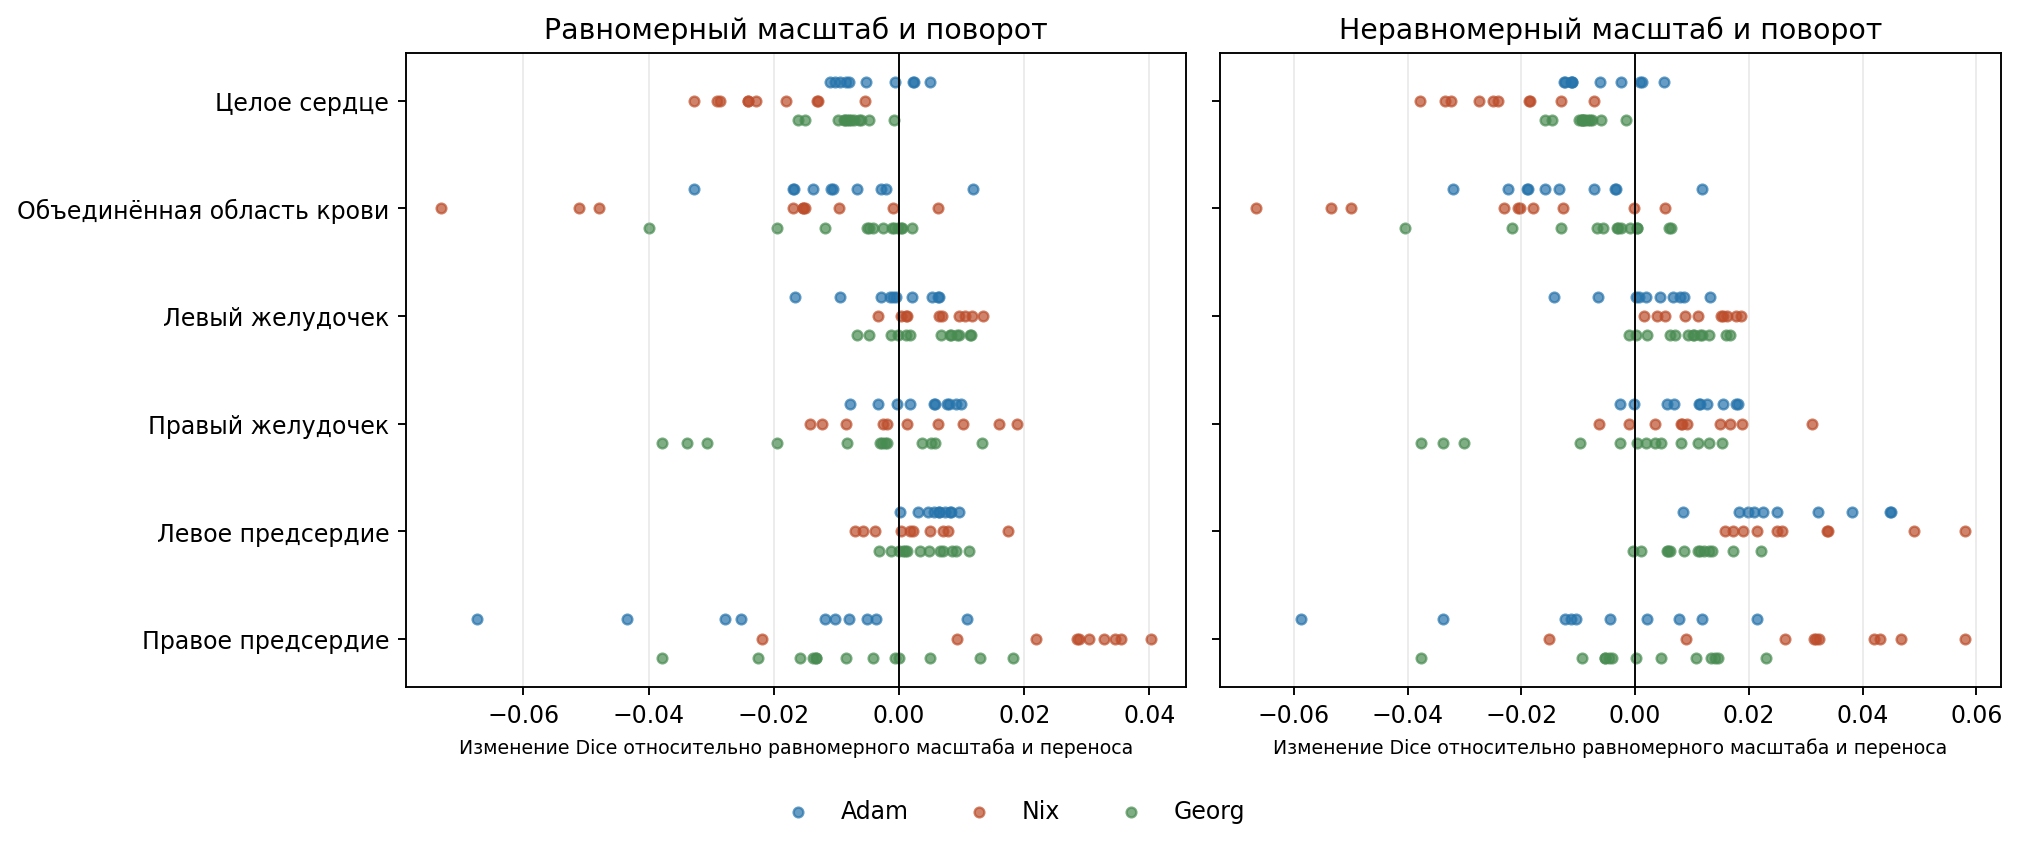

In [6]:
show_figure(report.affine_figure(records, affine), '03_affine.png')

**Рисунок 3. Изменение перекрытия после усложнения индивидуального преобразования.** Положительные значения означают улучшение относительно равномерного масштабирования и переноса, отрицательные — ухудшение. Каждая точка представляет парное сравнение одной фазы и области. Опорные фазы исключены.

Для целого сердца неравномерное масштабирование с поворотом улучшает перекрытие лишь в 3 из 33 неопорных фаз; для объединённой области крови — в 6 из 33. Медианные парные изменения Dice равны приблизительно −0,010 и −0,013 соответственно. Для левого и правого желудочков улучшение получено в 30 и 24 фазах из 33; медианные парные изменения составляют около +0,009 и +0,008. Следовательно, эффект усложнения зависит от выбранной области.

Этот отрицательный результат относится к конкретному способу определения параметров по моментам. Параметры не оптимизировались по Dice, поэтому расширение семейства преобразований не обязано улучшать данный критерий. Результат не доказывает невозможность более точного аффинного приближения. Он показывает, что автоматическое сопоставление главных осей недостаточно для выбора лучшего преобразования целого сердца и объединённой области крови.

## 5. Границы изображения и дискретизация

В таблице указано число фаз, в которых область касается хотя бы одной границы исходной КТ, и общее число фаз участника.

In [7]:
display(Markdown(report.qc_table(records)))

| Область | Adam | Nix | Georg |
| --- | --- | --- | --- |
| Целое сердце | 12 / 12 | 12 / 12 | 0 / 15 |
| Объединённая область крови | 1 / 12 | 0 / 12 | 0 / 15 |
| Левый желудочек | 0 / 12 | 0 / 12 | 0 / 15 |
| Правый желудочек | 1 / 12 | 0 / 12 | 0 / 15 |
| Левое предсердие | 0 / 12 | 0 / 12 | 0 / 15 |
| Правое предсердие | 0 / 12 | 0 / 12 | 0 / 15 |

Касание обнаружено в 26 из 234 сочетаний: 24 относятся к целому сердцу, по одному — к объединённой области крови и правому желудочку. У Adam и Nix целое сердце касается границы во всех фазах. По одному этому признаку нельзя различить обрезание анатомии и ошибку автоматической маски. Пока причина не установлена, вычисленные объёмы нельзя без дополнительной проверки считать полными анатомическими объёмами этих областей.

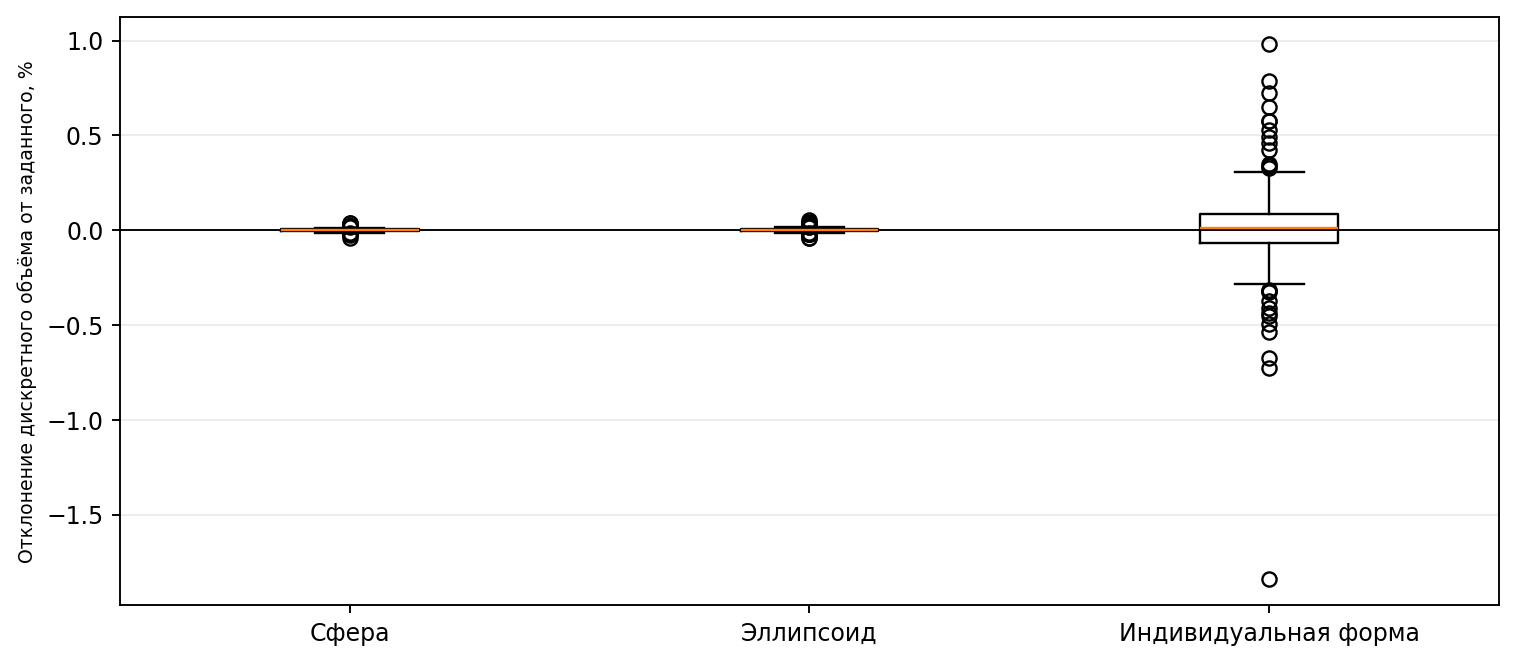

In [8]:
show_figure(report.discretization_figure(records), '04_discretization.png')

**Рисунок 4. Различие дискретного и заданного непрерывного объёмов кандидатов.** Непрерывный объём каждого кандидата равен объёму целевой маски по построению. На рисунке показано отличие после представления кандидата на сетке центров вокселей. Опорные фазы исключены.

Для сферы и эллипсоида принадлежность точки определяется аналитически. При представлении индивидуальной формы на сетке каждая точка обратным преобразованием переводится в координаты опорной маски, после чего выбирается ближайший воксель. Поэтому её дискретный объём может отклоняться заметнее, хотя непрерывное преобразование точно сохраняет заданное отношение объёмов. Это отдельный источник вычислительной погрешности, который нужно учитывать при переносе геометрии в FEM.

## 6. Восстановление исключённых фаз по временным моделям

Геометрическое сравнение использует параметры самой целевой фазы. Для проверки временной модели выполнен другой опыт: одна внутренняя фаза исключается, а её объём и центр предсказываются по остальным фазам того же человека и того же исходного цикла. Крайние доступные фазы не исключаются, поскольку их восстановление потребовало бы экстраполяции за наблюдаемый интервал.

Сравниваются постоянное значение по обучающим фазам, линейная интерполяция между соседними доступными фазами и одна периодическая гармоника. Моделируется логарифм численного значения объёма $V$, выраженного в мм³; обратное преобразование обеспечивает положительность восстановленного объёма. Поэтому постоянный прогноз объёма равен геометрическому среднему обучающих значений, а интерполяция соседних фаз линейна по логарифму объёма. Координаты центра моделируются непосредственно. Для гармоники используется выражение

$$y(\tau)=a_0+a_s\sin(2\pi\tau)+a_c\cos(2\pi\tau),$$

где $\tau$ — безразмерная доля данного R–R-интервала от 0 до 1; $y$ — логарифм численного значения объёма в мм³ либо одна координата центра в миллиметрах; $a_0,a_s,a_c$ — коэффициенты, оценённые только по обучающим фазам. Периодичность в этой модели является допущением. Внутреннее разбиение по фазам не проверяет перенос между людьми.

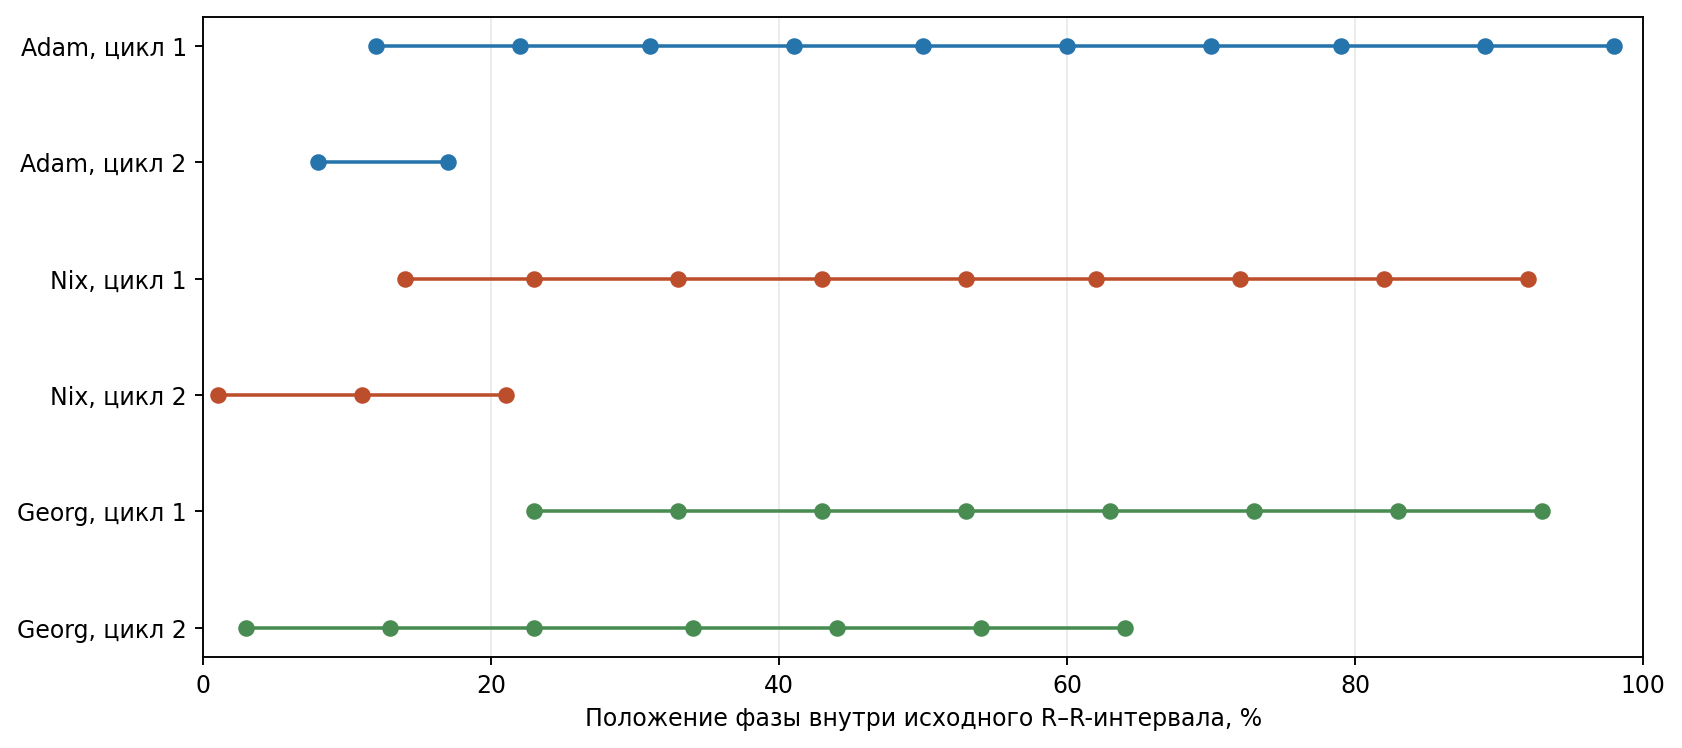

In [9]:
show_figure(report.coverage_figure(records), '05_coverage.png')

**Рисунок 5. Фактическое покрытие исходных сердечных циклов.** Точки показывают доступные фазы, линии соединяют их только внутри одного исходного R–R-интервала. Пропущенные участки цикла не являются наблюдениями.

Число фаз в шести исходных циклах составляет 10, 2, 9, 3, 8 и 7. Поэтому одинаковая сложность временной модели поддерживается не во всех циклах. Для гармоники требуется не менее пяти обучающих фаз и полный ранг матрицы регрессии. Шесть прогнозов одной фазы Nix — по числу областей — пропущены из-за недостатка обучающих фаз. Всего сохранено 480 прогнозов. Для сравнения трёх способов ниже используется только общее множество состояний, доступных всем трём способам.

In [10]:
display(Markdown(report.temporal_table(temporal)))

| Область | Способ | Число фаз | Медиана модуля относительной ошибки объёма, % | Максимум модуля относительной ошибки объёма, % | Медиана расстояния между центрами, мм |
| --- | --- | --- | --- | --- | --- |
| Целое сердце | Постоянное значение | 26 | 5,06 | 9,61 | 0,97 |
| Целое сердце | Интерполяция между соседними фазами | 26 | 0,68 | 3,51 | 0,38 |
| Целое сердце | Одна гармоника | 26 | 1,12 | 3,23 | 0,47 |
| Объединённая область крови | Постоянное значение | 26 | 5,40 | 10,19 | 1,27 |
| Объединённая область крови | Интерполяция между соседними фазами | 26 | 1,07 | 4,13 | 0,44 |
| Объединённая область крови | Одна гармоника | 26 | 0,90 | 4,12 | 0,55 |
| Левый желудочек | Постоянное значение | 26 | 12,98 | 36,18 | 2,58 |
| Левый желудочек | Интерполяция между соседними фазами | 26 | 2,79 | 15,54 | 0,83 |
| Левый желудочек | Одна гармоника | 26 | 4,30 | 15,08 | 0,69 |
| Правый желудочек | Постоянное значение | 26 | 14,73 | 44,37 | 3,50 |
| Правый желудочек | Интерполяция между соседними фазами | 26 | 3,65 | 14,57 | 1,15 |
| Правый желудочек | Одна гармоника | 26 | 5,93 | 16,33 | 1,63 |
| Левое предсердие | Постоянное значение | 26 | 14,57 | 36,74 | 3,51 |
| Левое предсердие | Интерполяция между соседними фазами | 26 | 4,83 | 20,90 | 1,20 |
| Левое предсердие | Одна гармоника | 26 | 5,33 | 34,54 | 1,39 |
| Правое предсердие | Постоянное значение | 26 | 12,24 | 34,24 | 3,51 |
| Правое предсердие | Интерполяция между соседними фазами | 26 | 5,93 | 24,86 | 1,62 |
| Правое предсердие | Одна гармоника | 26 | 4,16 | 32,92 | 1,79 |

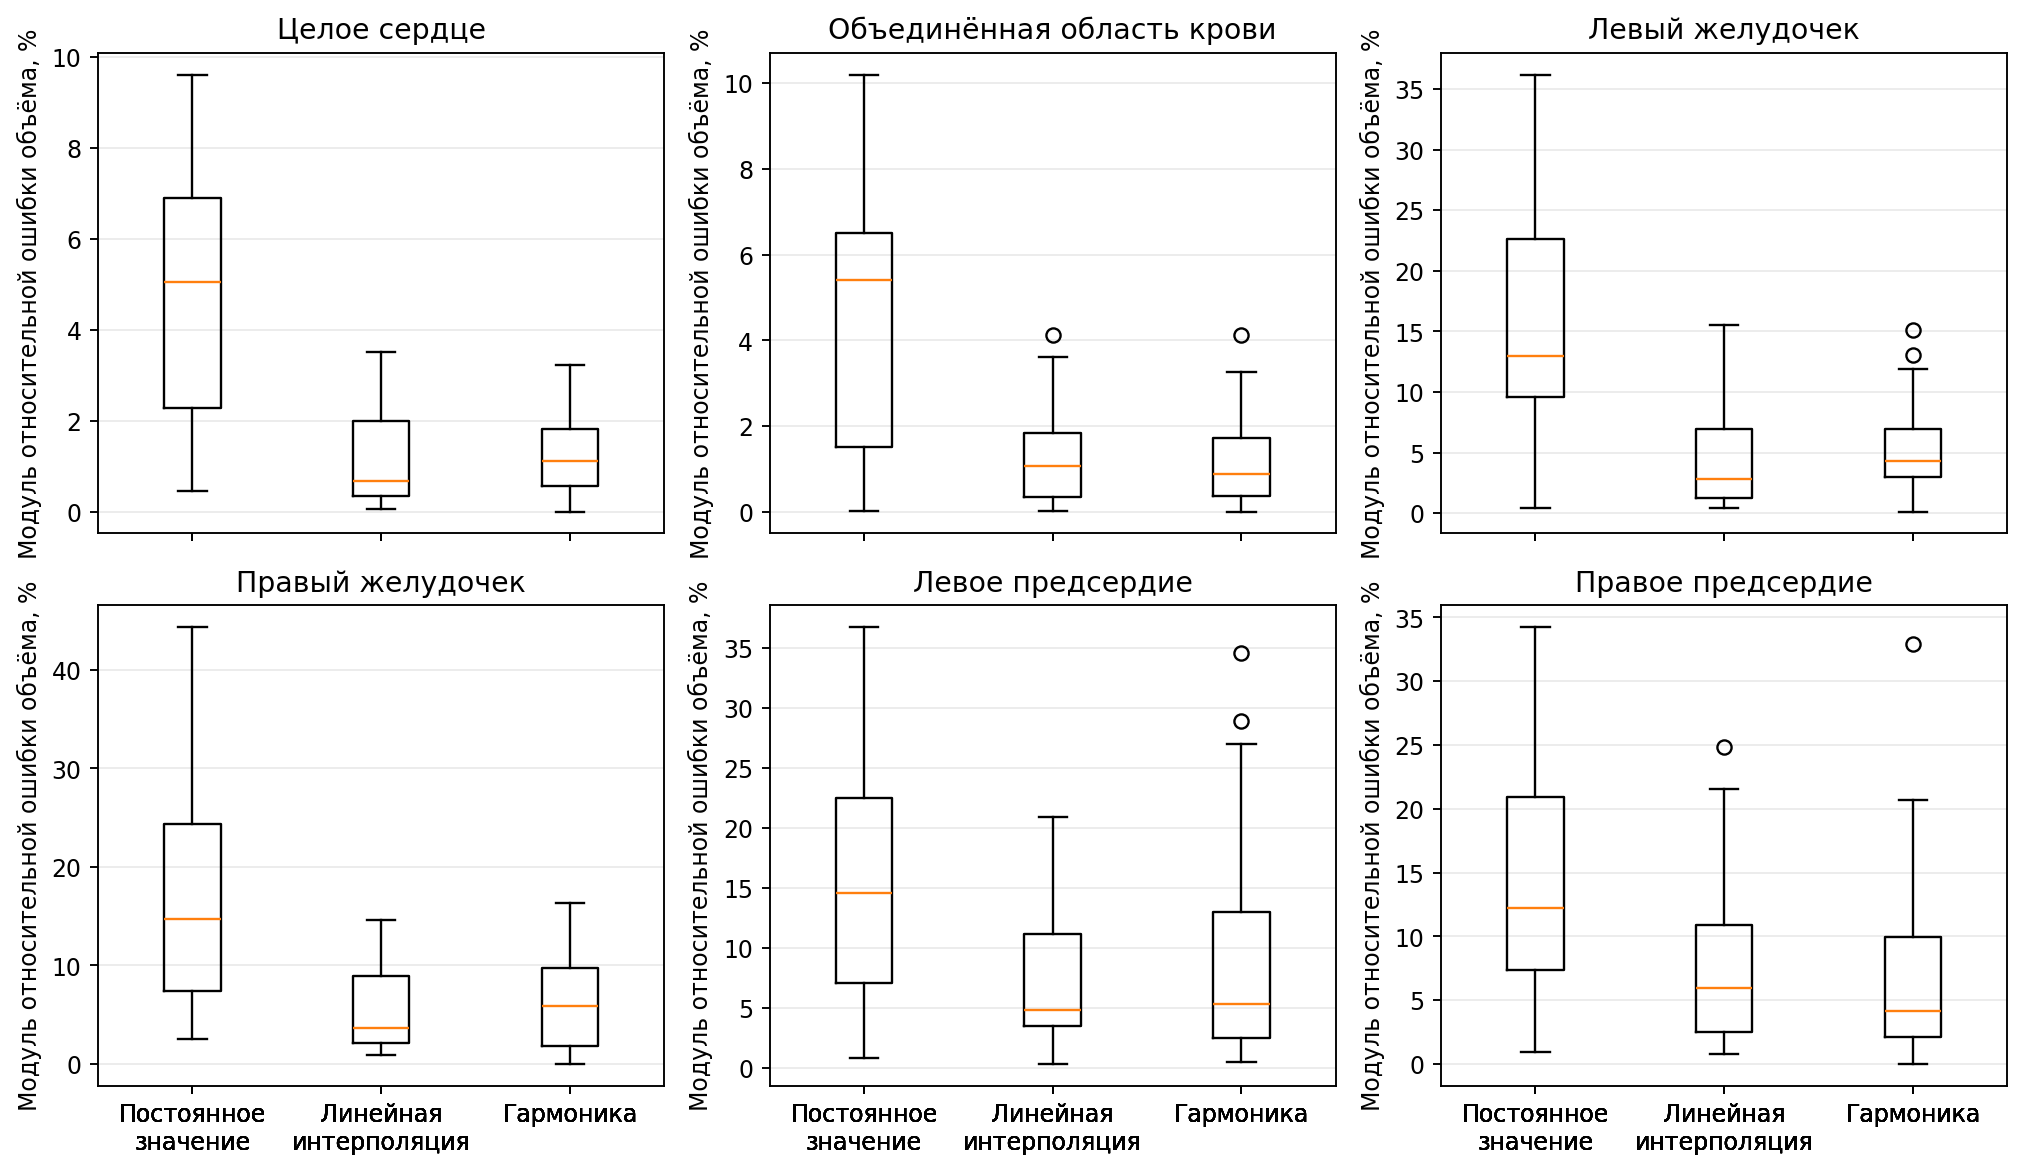

In [11]:
show_figure(report.temporal_figure(temporal), '06_temporal.png')

**Рисунок 6. Ошибка восстановления объёма исключённой фазы.** Представлены абсолютные относительные ошибки на общем наборе фаз. Центральная линия показывает медиану; коробка — межквартильный диапазон; усы доходят до крайних наблюдений в пределах полутора межквартильных диапазонов от коробки; более удалённые значения показаны точками. Они не удаляются из расчёта. Для каждой области используется собственная вертикальная шкала, обозначенная в процентах.

Интерполяция соседних фаз использует локально доступную информацию и служит контрольным способом восстановления. Она не является компактным общим законом: для неё необходимо сохранять множество исходных фаз. Гармоническая модель задаётся тремя коэффициентами для каждой моделируемой величины и потенциально сокращает объём описания. Её пригодность нужно оценивать по ошибке исключённых фаз, а не по гладкости кривой или совпадению с обучающими точками. Малые средние ошибки также не исключают значительных ошибок отдельных фаз.

## 7. Критерии следующего этапа и ограничения вывода

В этом опыте подтверждена внутренняя согласованность геометрических вычислений и выполнена условная проверка восстановления отдельных фаз. Анатомическая точность сегментации, физическая эквивалентность замещений и точность функций сердца не валидированы.

Для дальнейшего выбора необходимо разделить четыре ошибки: ошибку автоматической маски относительно независимого анатомического референса; потерю формы при замещении; ошибку временного закона; изменение электрического отклика при замещении. Ни одна из них не заменяет остальные. Совпадение объёмов по построению не проверяет точность межфазного изменения объёма исходных масок.

Дополнительный геометрический опыт с поворотом и раздельными масштабами выполнен. Его неодинаковые результаты для разных областей требуют проверки способа определения параметров и не дают основания повсеместно заменять начальную индивидуальную модель более сложной. FEM-сравнение необходимо выполнять при одинаковых электродах и тканевых свойствах, с проверкой совмещения геометрий, правил замещения материалов и пространственной сходимости. Требуются базовый импеданс, его межфазное изменение и производные по независимым координатам и объёму.

Численные допуски окончательного физиологического и электрического выбора пока не обоснованы. Поэтому настоящий результат не определяет оптимальную модель. Он устанавливает геометрическое преимущество эллипсоида относительно сферы на принятых автоматических масках и формирует проверяемую основу для следующего опыта.



## 8. Принятое правило замещения тканей

По решению автора применяется неподвижный фон без сердца. В нём сохраняются
исходные лёгкие, мягкие ткани и отдельный костный материал. Область исходного
сердца при построении фона относится к мягким тканям. Это принятое упрощение
материальной модели; оно не описывает механическое перемещение окружающих
органов.

Карта материалов при заданной геометрии сердца определяется правилом

$$
M(\mathbf x;\theta)=
\begin{cases}
\text{сердце}, & \mathbf x\in H(\theta),\\
B(\mathbf x), & \mathbf x\notin H(\theta)
\end{cases},
$$

где $\mathbf x$ — точка в физической системе координат; $\theta$ — параметры
геометрии сердца; $H(\theta)$ — занимаемая им область; $B(\mathbf x)$ — материал
неизменного фона в этой точке; $M(\mathbf x;\theta)$ — материал, назначенный
точке после наложения сердца.

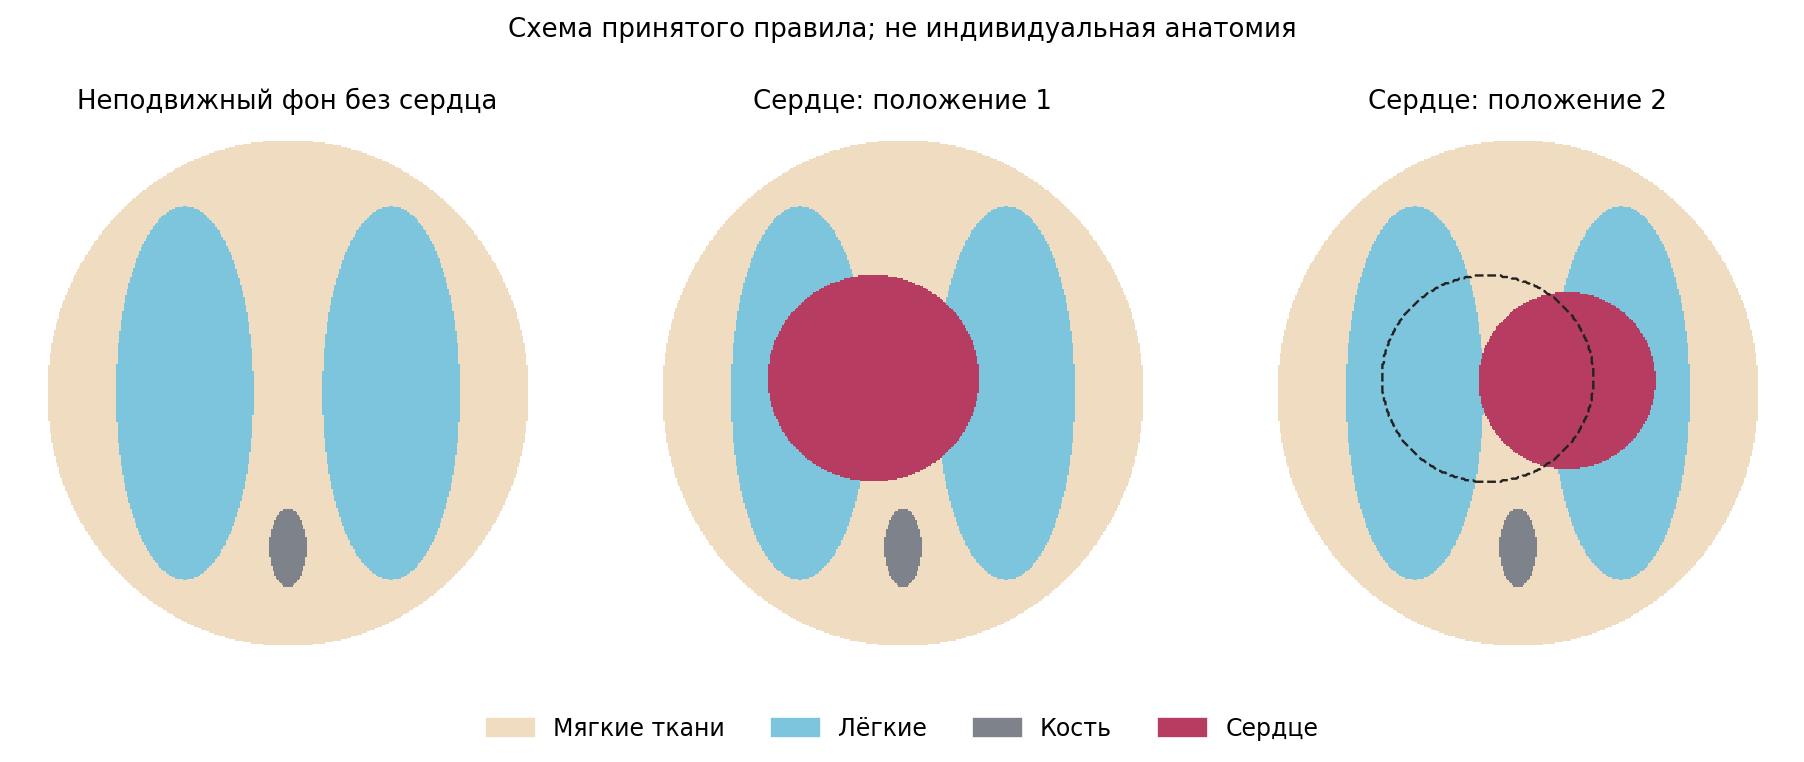

In [12]:
show_figure(report.overlay_schematic(), '07_overlay.png')

**Рисунок 7. Наложение сердца на неизменный фон.** Слева показан фон без сердца. В двух следующих состояниях сердце получает приоритет внутри своей области. Пунктир справа обозначает прежнюю область сердца: её освободившиеся части снова имеют свойства фоновых тканей. Формы и положения условны и служат только объяснению принятого правила.

Каждое состояние вычисляется из одной и той же сохранённой фоновой карты.
Нельзя строить новый кадр только изменением меток предыдущего кадра:
иначе после освобождения области можно потерять сведения о её исходной ткани.
При возвращении к прежнему положению и размеру должна точно восстанавливаться
прежняя карта материалов. Наложение исходной сердечной области на фон должно
воспроизводить исходную разметку на четыре материала: сердце, лёгкие, кость и мягкие ткани.

Пересечение эквивалентного сердца с лёгкими или мягкими тканями допускается
и не является основанием отклонения геометрии. Сердце получает приоритет
в занимаемой области. После её освобождения восстанавливается фоновый
материал, включая кость, если она была задана в этой точке. Объём пересечения
может сохраняться как описательная характеристика изменения материалов.
Фоновая маска лёгких при этом неподвижна, но объём, которому в конкретном
состоянии назначены электрические свойства лёгкого, изменяется за счёт
области, занятой сердцем.

При неизменных проводимостях тканей изменение геометрии даёт

$$
\Delta\sigma(\mathbf x)=
[\sigma_H-\sigma_B(\mathbf x)]
[\chi_{H(\theta_2)}(\mathbf x)-\chi_{H(\theta_1)}(\mathbf x)],
$$

где $\Delta\sigma(\mathbf x)$ — изменение проводимости в точке $\mathbf x$
при переходе от параметров $\theta_1$ к $\theta_2$; $\sigma_H$ — проводимость,
назначенная области сердца; $\sigma_B(\mathbf x)$ — проводимость фоновой ткани;
$\chi_{H(\theta)}(\mathbf x)$ равен 1 внутри области сердца и 0 вне её.
Следовательно, электрический отклик на изменение геометрии зависит от контраста
проводимостей сердца и той ткани, которую оно замещает. Это результат
принятой материальной постановки, а не самостоятельное доказательство
механической или физиологической эквивалентности.

Правило устраняет неопределённость назначения материалов при пересечениях.
Проверки единиц и систем координат, внешней границы расчётного тела,
численной сходимости и корректности производных сохраняются. Ошибку
исходной сегментации и потерю анатомии за границами КТ также нужно
рассматривать отдельно от допустимого наложения сердечной модели на фон.

## 8.1. Проверка назначения материалов на статической сетке

На имеющейся статической конечноэлементной сетке подготовлены карты материалов для исходной области сердца, сферы и эллипсоида. Результаты получены программной проверкой назначения материалов и расчётом объёмов тетраэдров; их численные значения взяты из сохранённых протоколов и таблицы баланса объёмов. Сетка содержит 791 141 узел и 4 448 426 тетраэдров.

Фоновая карта лёгких, кости и мягких тканей используется только для чтения. Наложение исходной области сердца точно воспроизводит исходную разметку. Во всех девяти проверенных переходах между тремя вариантами фон восстанавливается, а результат назначения материалов не зависит от порядка переходов. Сфера и эллипсоид не касаются внешней граничной триангуляции этой сетки. Исходные входы не перезаписаны; для каждого варианта сохранены метки материалов и условия их назначения.

В таблице сопоставлены непрерывный объём области сердца и объём по дискретной разметке сетки. Разность вычислена как дискретный объём минус непрерывный.

| Вариант | Непрерывный объём, мл | Объём по разметке сетки, мл | Разность, мл |
|---|---|---|---|
| Исходная область сердца | 782,892 | 782,892 | 0,000 |
| Сфера | 782,892 | 784,390 | +1,498 |
| Эллипсоид | 782,892 | 781,555 | −1,337 |

Непрерывная равновеликость обеспечена построением. Отклонения дискретных объёмов характеризуют представление заданной геометрии на этой сетке и не отменяют равенства непрерывных объёмов.

Выполнен статический контроль правила назначения материалов. Он не подтверждает физическую или анатомическую эквивалентность моделей и не является проверкой совмещения 4D-геометрий. Новые конечноэлементные матрицы и импедансы $Z$ в этом контроле не вычислялись.

## Воспроизводимость

Использованы сохранённые результаты начального геометрического сравнения, его расширения с поворотом и неравномерным масштабированием, а также отдельной проверки временных зависимостей. В локальных результатах сохранены контрольные суммы входов, версии вычислительных модулей, параметры, индивидуальные циклы и статусы проверок. Кодовые ячейки этого ноутбука формируют таблицы и рисунки из сохранённых численных результатов; они не запускают сегментацию или FEM. Читательский HTML содержит только текст и расчётные выходы.

Методологические варианты и литературные основания обсуждаются в [обзоре 40.15](40.15_Эквивалентная_сфера_сердца_методики_и_проверка.ipynb). Последовательность дальнейших проверок закреплена в [плане исполнения](40.15_План_исполнения_сравнения_моделей_сердца.md).